# Experiment 6: LightGBM detailed hyperparameter tuning

100 Optuna trials over 9 LightGBM hyperparameters; every trial is logged to MLflow.

Fixes compared with the original notebook:
- **Data leakage.** The original fitted TF-IDF and SMOTE on the *whole* dataset before splitting,
  so synthetic copies of test comments ended up in training and inflated the score.
  Here the data is split first; TF-IDF and SMOTE only ever see training rows.
- **Tuning on the test set.** Trials are scored on a validation split; the test set is used once at the end.
- **`subsample` did nothing.** LightGBM ignores `subsample` unless `subsample_freq > 0`; it is set to 1.
- Only the best model's artifact is logged (logging 100 models costs gigabytes for no benefit).

In [1]:
import os
from datetime import datetime

import matplotlib.pyplot as plt
import mlflow
import mlflow.sklearn
import optuna
import pandas as pd
import seaborn as sns
from imblearn.over_sampling import SMOTE
from lightgbm import LGBMClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

mlflow.set_tracking_uri(os.getenv('MLFLOW_TRACKING_URI', 'http://127.0.0.1:5000'))
EXPERIMENT = 'Exp 6 - LightGBM HP Tuning'
mlflow.set_experiment(EXPERIMENT)
BATCH = datetime.now().strftime('%Y%m%d-%H%M%S')
optuna.logging.set_verbosity(optuna.logging.WARNING)

N_TRIALS = 100
NGRAM_RANGE = (1, 3)
MAX_FEATURES = 1000

D:\Tech stuff\youtube viewer sentiment analyzer\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


2026/09/12 08:58:42 INFO mlflow.tracking.fluent: Experiment with name 'Exp 6 - LightGBM HP Tuning' does not exist. Creating a new experiment.


In [2]:
df = pd.read_csv('reddit_preprocessing.csv').dropna(subset=['clean_comment'])

# Same label mapping as experiment 5 so results are comparable; reports map 2 back to -1
TO_MODEL = {-1: 2, 0: 0, 1: 1}
TO_LABEL = {v: k for k, v in TO_MODEL.items()}
df['category'] = df['category'].map(TO_MODEL)

X_train_text, X_test_text, y_train_raw, y_test = train_test_split(
    df['clean_comment'], df['category'], test_size=0.2, random_state=42, stratify=df['category']
)
X_fit_text, X_val_text, y_fit_raw, y_val = train_test_split(
    X_train_text, y_train_raw, test_size=0.2, random_state=42, stratify=y_train_raw
)


def build_features(train_text, train_labels, *eval_texts):
    """Fit TF-IDF on the training text, oversample it with SMOTE, and transform the evaluation text."""
    vectorizer = TfidfVectorizer(ngram_range=NGRAM_RANGE, max_features=MAX_FEATURES)
    X = vectorizer.fit_transform(train_text)
    X, y = SMOTE(random_state=42).fit_resample(X, train_labels)
    return (X, y, *[vectorizer.transform(t) for t in eval_texts])


X_fit, y_fit, X_val = build_features(X_fit_text, y_fit_raw, X_val_text)
X_train, y_train, X_test = build_features(X_train_text, y_train_raw, X_test_text)
X_fit.shape, X_val.shape, X_train.shape, X_test.shape

((30279, 1000), (5866, 1000), (37848, 1000), (7333, 1000))

In [3]:
def build_lgbm(trial):
    return LGBMClassifier(
        n_estimators=trial.suggest_int('n_estimators', 100, 1000),
        learning_rate=trial.suggest_float('learning_rate', 1e-4, 1e-1, log=True),
        max_depth=trial.suggest_int('max_depth', 3, 15),
        num_leaves=trial.suggest_int('num_leaves', 20, 150),
        min_child_samples=trial.suggest_int('min_child_samples', 10, 100),
        colsample_bytree=trial.suggest_float('colsample_bytree', 0.5, 1.0),
        subsample=trial.suggest_float('subsample', 0.5, 1.0),
        subsample_freq=1,
        reg_alpha=trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        reg_lambda=trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        random_state=42,
        n_jobs=-1,
        verbose=-1,
    )


def objective(trial):
    model = build_lgbm(trial)
    with mlflow.start_run(run_name=f'Trial_{trial.number}_LightGBM_SMOTE_TFIDF_Trigrams'):
        mlflow.set_tags({'experiment_type': 'hyperparameter_tuning', 'batch': BATCH})
        mlflow.log_params({'algo_name': 'LightGBM', **trial.params})
        val_accuracy = accuracy_score(y_val, model.fit(X_fit, y_fit).predict(X_val))
        mlflow.log_metric('val_accuracy', val_accuracy)
    return val_accuracy


study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=N_TRIALS)
print(f'Best validation accuracy: {study.best_value:.4f}')
study.best_params

2026/09/12 08:59:02 INFO mlflow.tracking._tracking_service.client: 🏃 View run Trial_0_LightGBM_SMOTE_TFIDF_Trigrams at: http://127.0.0.1:5000/#/experiments/7/runs/12e1aa267e524825b763f484006d2f07.


2026/09/12 08:59:02 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: http://127.0.0.1:5000/#/experiments/7.


2026/09/12 08:59:37 INFO mlflow.tracking._tracking_service.client: 🏃 View run Trial_1_LightGBM_SMOTE_TFIDF_Trigrams at: http://127.0.0.1:5000/#/experiments/7/runs/bd85588803a54e85867d4e0e0a886632.


2026/09/12 08:59:37 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: http://127.0.0.1:5000/#/experiments/7.


2026/09/12 08:59:50 INFO mlflow.tracking._tracking_service.client: 🏃 View run Trial_2_LightGBM_SMOTE_TFIDF_Trigrams at: http://127.0.0.1:5000/#/experiments/7/runs/d48389c9dbd440818baf0f67465ae638.


...

2026/09/12 09:13:44 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: http://127.0.0.1:5000/#/experiments/7.


2026/09/12 09:13:53 INFO mlflow.tracking._tracking_service.client: 🏃 View run Trial_99_LightGBM_SMOTE_TFIDF_Trigrams at: http://127.0.0.1:5000/#/experiments/7/runs/6bbc9b6e5e5f4483974b102501f5ca22.


2026/09/12 09:13:53 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: http://127.0.0.1:5000/#/experiments/7.


Best validation accuracy: 0.7976


{'n_estimators': 506,
 'learning_rate': 0.043627859947423304,
 'max_depth': 9,
 'num_leaves': 39,
 'min_child_samples': 20,
 'colsample_bytree': 0.7374583268296138,
 'subsample': 0.6735949428661002,
 'reg_alpha': 0.01195218667407998,
 'reg_lambda': 0.09380272486941937}

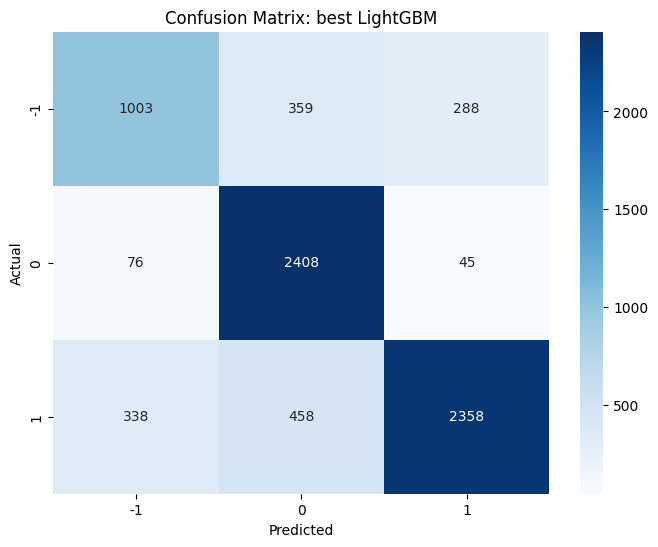

2026/09/12 09:14:10 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


2026/09/12 09:14:10 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


2026/09/12 09:14:10 INFO mlflow.tracking._tracking_service.client: 🏃 View run Trial_Best_LightGBM_SMOTE_TFIDF_Trigrams at: http://127.0.0.1:5000/#/experiments/7/runs/fcc440825fc3433cae01af138c61c82c.


2026/09/12 09:14:10 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: http://127.0.0.1:5000/#/experiments/7.


              precision    recall  f1-score   support

          -1       0.71      0.61      0.65      1650
           0       0.75      0.95      0.84      2529
           1       0.88      0.75      0.81      3154

    accuracy                           0.79      7333
   macro avg       0.78      0.77      0.77      7333
weighted avg       0.79      0.79      0.78      7333



In [4]:
best_model = build_lgbm(optuna.trial.FixedTrial(study.best_params))
best_model.fit(X_train, y_train)
y_true = y_test.map(TO_LABEL)
y_pred = pd.Series(best_model.predict(X_test)).map(TO_LABEL)

with mlflow.start_run(run_name='Trial_Best_LightGBM_SMOTE_TFIDF_Trigrams'):
    mlflow.set_tags({'experiment_type': 'hyperparameter_tuning', 'batch': BATCH, 'best': 'true'})
    mlflow.log_params({'algo_name': 'LightGBM', **study.best_params})
    mlflow.log_metric('val_accuracy', study.best_value)
    mlflow.log_metric('accuracy', accuracy_score(y_true, y_pred))
    for label, metrics in classification_report(y_true, y_pred, output_dict=True).items():
        if isinstance(metrics, dict):
            mlflow.log_metrics({f'{label}_{name}': value for name, value in metrics.items()})

    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(confusion_matrix(y_true, y_pred, labels=[-1, 0, 1]), annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=[-1, 0, 1], yticklabels=[-1, 0, 1])
    ax.set(xlabel='Predicted', ylabel='Actual', title='Confusion Matrix: best LightGBM')
    mlflow.log_figure(fig, 'confusion_matrix.png')
    plt.show()

    mlflow.sklearn.log_model(best_model, 'LightGBM_model')

print(classification_report(y_true, y_pred))

C:\Users\<user>\AppData\Local\Temp\ipykernel_15188\429335526.py:1: ExperimentalWarning: plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_param_importances(study)


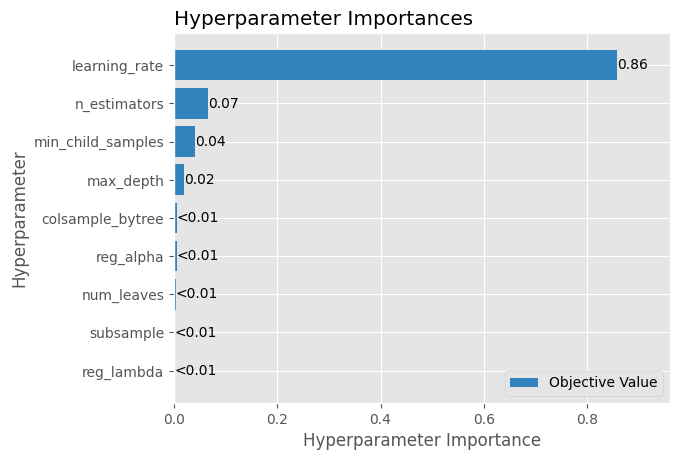

In [5]:
optuna.visualization.matplotlib.plot_param_importances(study)
plt.show()

C:\Users\<user>\AppData\Local\Temp\ipykernel_15188\3222002628.py:1: ExperimentalWarning: plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_optimization_history(study)


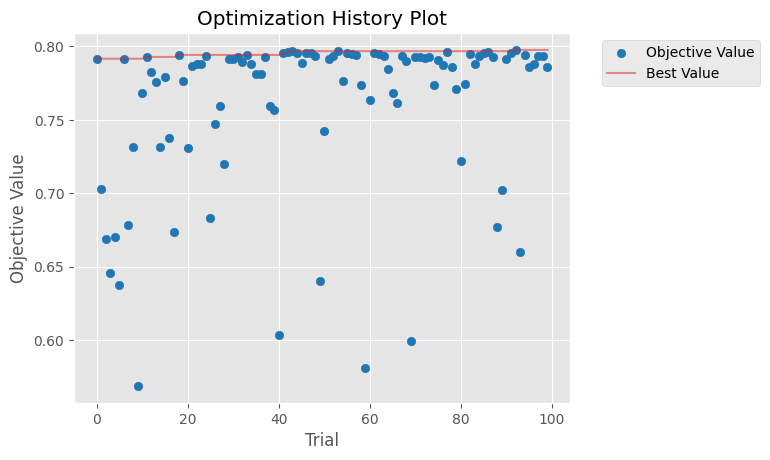

In [6]:
optuna.visualization.matplotlib.plot_optimization_history(study)
plt.show()

In [7]:
top_trials = study.trials_dataframe().sort_values('value', ascending=False).head(10)
top_trials.filter(regex='^(number|value|params_)').round(4)

,number,value,params_colsample_bytree,params_learning_rate,params_max_depth,params_min_child_samples,params_n_estimators,params_num_leaves,params_reg_alpha,params_reg_lambda,params_subsample
92,92,0.7976,0.7375,0.0436,9,20,506,39,0.0120,0.0938,0.6736
43,43,0.7968,0.7248,0.0496,10,18,441,35,0.0039,0.0311,0.6725
53,53,0.7968,0.7369,0.0489,8,24,507,42,0.0032,0.0206,0.7389
42,42,0.7963,0.6770,0.0526,9,14,418,35,0.0116,0.0145,0.6751
77,77,0.7963,0.7326,0.0454,8,28,537,43,0.0043,0.0031,0.6977
86,86,0.7959,0.7248,0.0369,10,23,444,59,0.0030,0.0085,0.6708
47,47,0.7958,0.7685,0.0491,7,26,537,37,0.0003,0.0189,0.7086
44,44,0.7958,0.7270,0.0429,10,17,452,35,0.0040,0.0336,0.6759
46,46,0.7956,0.7671,0.0453,8,18,524,39,0.0004,0.0127,0.7079
55,55,0.7956,0.7513,0.0473,8,30,642,47,0.0006,0.0225,0.6913
